# Actividad 1: Interpretabilidad de Modelos
## Análisis de Datos II - CEIA 4B2026

**Dataset:** [Data Science Salaries 2023](https://www.kaggle.com/datasets/arnabchaki/data-science-salaries-2023)

**Objetivo:** Entrenar un modelo basado en árboles para predecir `salary_in_usd` y analizar su comportamiento mediante técnicas de interpretabilidad global (PFI) y local (SHAP).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OrdinalEncoder
import shap
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
shap.initjs()

## 1. Carga y exploración de datos

In [2]:
df = pd.read_csv('data/ds_salaries.csv')
print(f'Dimensiones: {df.shape}')
df.head()

Dimensiones: (3755, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           3755 non-null   int64
 1   experience_level    3755 non-null   str  
 2   employment_type     3755 non-null   str  
 3   job_title           3755 non-null   str  
 4   salary              3755 non-null   int64
 5   salary_currency     3755 non-null   str  
 6   salary_in_usd       3755 non-null   int64
 7   employee_residence  3755 non-null   str  
 8   remote_ratio        3755 non-null   int64
 9   company_location    3755 non-null   str  
 10  company_size        3755 non-null   str  
dtypes: int64(4), str(7)
memory usage: 322.8 KB


In [4]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


In [5]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nDuplicados: {df.duplicated().sum()}')

Valores nulos por columna:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Duplicados: 1171


In [6]:
print('Variables categóricas - valores únicos:')
for col in df.select_dtypes(include='object').columns:
    print(f'  {col}: {df[col].nunique()} valores únicos')

Variables categóricas - valores únicos:
  experience_level: 4 valores únicos
  employment_type: 4 valores únicos
  job_title: 93 valores únicos
  salary_currency: 20 valores únicos
  employee_residence: 78 valores únicos
  company_location: 72 valores únicos
  company_size: 3 valores únicos


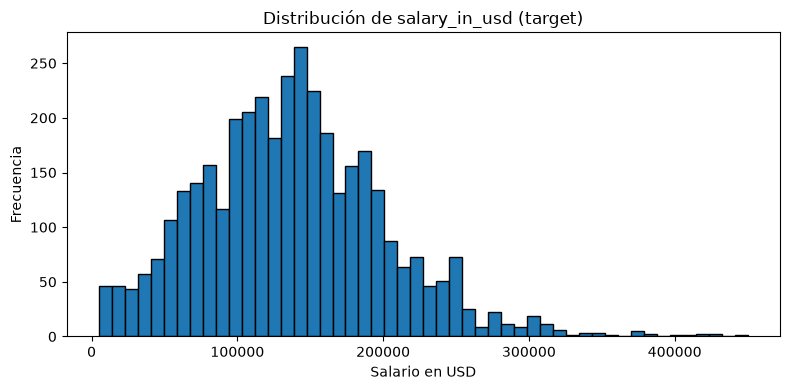

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['salary_in_usd'], bins=50, edgecolor='black')
ax.set_xlabel('Salario en USD')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de salary_in_usd (target)')
plt.tight_layout()
plt.show()

Observación: `salary` y `salary_currency` representan el salario en la moneda original. Dado que el target es `salary_in_usd`, estas variables podrían contener información directamente derivada del target (data leakage potencial). Las incluimos inicialmente para diagnosticar este comportamiento con las técnicas de interpretabilidad.

## 2. Preparación de datos y entrenamiento

In [8]:
TARGET = 'salary_in_usd'

y = df[TARGET]
X = df.drop(columns=[TARGET])

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print(f'Features categóricas: {cat_cols}')
print(f'Features numéricas: {num_cols}')

Features categóricas: ['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']
Features numéricas: ['work_year', 'salary', 'remote_ratio']


In [9]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_encoded = X.copy()
X_encoded[cat_cols] = encoder.fit_transform(X[cat_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 3004 | Test: 751


In [10]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Métricas en test:')
print(f'  R²:   {r2_score(y_test, y_pred):.4f}')
print(f'  MAE:  {mean_absolute_error(y_test, y_pred):,.0f} USD')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f} USD')

Métricas en test:
  R²:   0.9761
  MAE:  1,524 USD
  RMSE: 9,717 USD


El modelo obtiene un R² muy alto, lo cual en principio parece bueno, pero como veremos en el diagnóstico, puede estar inflado por data leakage.

## 3. Diagnóstico Global: Permutation Feature Importance (PFI)

In [11]:
pfi_result = permutation_importance(
    model, X_test, y_test,
    n_repeats=30,
    random_state=42,
    scoring='r2'
)

pfi_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': pfi_result.importances_mean,
    'importance_std': pfi_result.importances_std
}).sort_values('importance_mean', ascending=False)

pfi_df

,feature,importance_mean,importance_std
4,salary,1.906249,0.073592
5,salary_currency,0.438797,0.038832
1,experience_level,0.003165,0.001013
6,employee_residence,0.001530,0.003498
0,work_year,0.001386,0.000399
8,company_location,0.001187,0.000570
9,company_size,0.001152,0.000356
7,remote_ratio,0.000826,0.002146
2,employment_type,0.000152,0.000263
3,job_title,-0.002629,0.002947


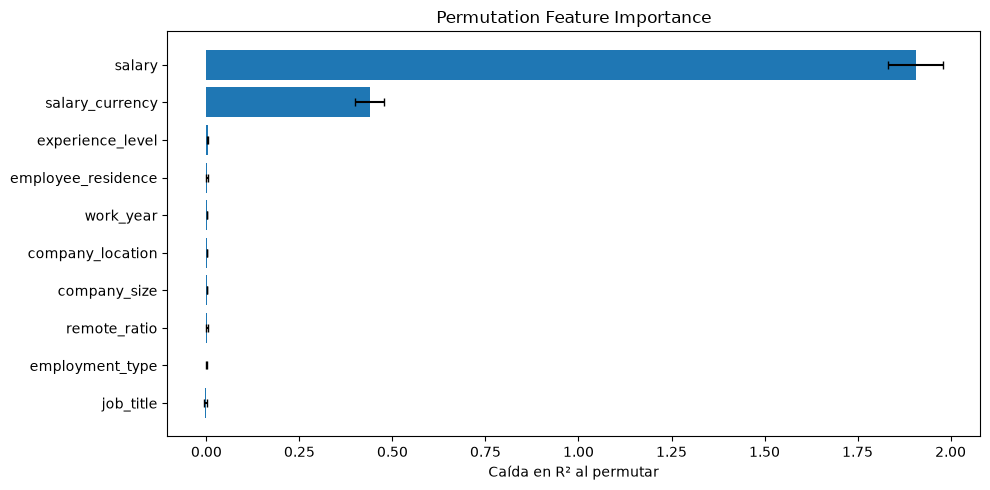

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
pfi_sorted = pfi_df.sort_values('importance_mean', ascending=True)
ax.barh(pfi_sorted['feature'], pfi_sorted['importance_mean'],
        xerr=pfi_sorted['importance_std'], capsize=3)
ax.set_xlabel('Caída en R² al permutar')
ax.set_title('Permutation Feature Importance')
plt.tight_layout()
plt.show()

### Análisis del PFI

Se observa que la variable `salary` domina ampliamente la importancia del modelo, con un valor desproporcionadamente alto respecto al resto de las features. Esto es una señal clara de **data leakage**: `salary` es el mismo salario expresado en la moneda local, y `salary_in_usd` es su conversión a dólares. El modelo está "prediciendo" el target a partir de una transformación casi directa del mismo.

Complementariamente, `salary_currency` también aparece con importancia relevante, ya que es el factor de conversión necesario para pasar de `salary` a `salary_in_usd`.

El resto de las variables (experience_level, job_title, etc.) muestran importancia marginal, lo cual es sospechoso: en un problema real de predicción de salarios, esperaríamos que el nivel de experiencia y el puesto fueran determinantes.

## 4. Diagnóstico Local: SHAP

In [13]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

base_value = float(np.mean(explainer.expected_value))
print(f'Valor base (promedio de predicciones): {base_value:,.0f} USD')
print(f'Shape de shap_values: {shap_values.shape}')

Valor base (promedio de predicciones): 137,991 USD
Shape de shap_values: (751, 10)


### Selección de observaciones

Seleccionamos dos observaciones con predicciones contrastantes:
- **Observación A:** predicción alta (salario alto)
- **Observación B:** predicción baja (salario bajo)

In [14]:
errors = np.abs(y_test.values - y_pred)

idx_high = np.argmax(y_pred)
idx_low = np.argmin(y_pred)

print(f'Observación A (predicción alta):')
print(f'  Predicción: {y_pred[idx_high]:,.0f} USD | Real: {y_test.iloc[idx_high]:,.0f} USD | Error: {errors[idx_high]:,.0f} USD')
print(f'\nObservación B (predicción baja):')
print(f'  Predicción: {y_pred[idx_low]:,.0f} USD | Real: {y_test.iloc[idx_low]:,.0f} USD | Error: {errors[idx_low]:,.0f} USD')

Observación A (predicción alta):
  Predicción: 379,566 USD | Real: 375,000 USD | Error: 4,566 USD

Observación B (predicción baja):
  Predicción: 7,547 USD | Real: 7,000 USD | Error: 547 USD


In [15]:
print('Observación A - valores de las features:')
display(X_test.iloc[[idx_high]])
print('\nObservación B - valores de las features:')
display(X_test.iloc[[idx_low]])

Observación A - valores de las features:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size
2359,2022,3.0,2.0,46.0,375000,19.0,75.0,50,70.0,0.0



Observación B - valores de las features:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size
573,2023,0.0,2.0,9.0,7000,19.0,30.0,0,29.0,2.0


### SHAP Waterfall - Observación A (predicción alta)

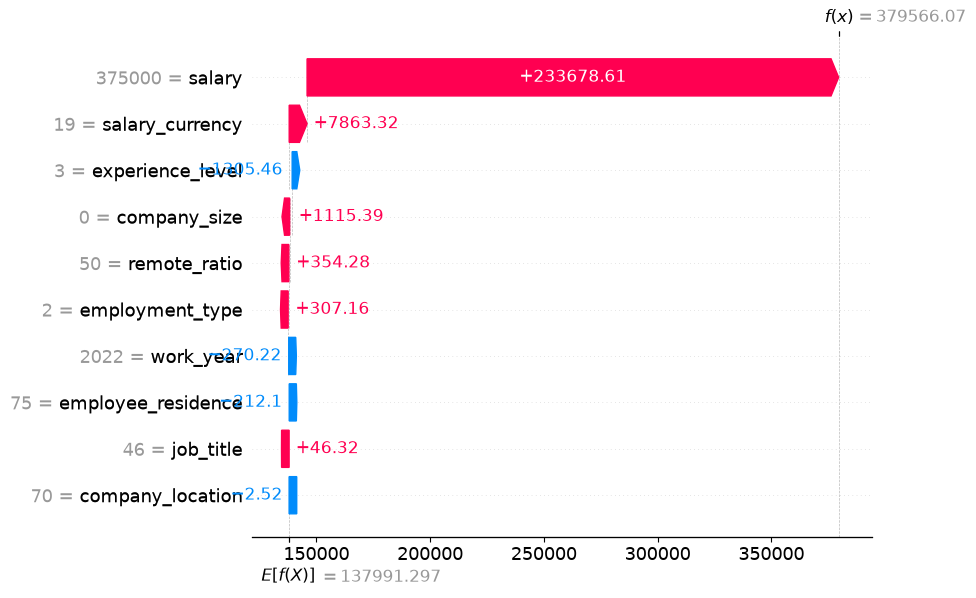

In [16]:
shap.plots.waterfall(shap_values[idx_high], max_display=12)

La variable `salary` domina completamente la explicación, empujando la predicción muy por encima del valor base. Esto es consistente con el diagnóstico global: el modelo depende casi exclusivamente de esta variable para realizar predicciones altas.

### SHAP Waterfall - Observación B (predicción baja)

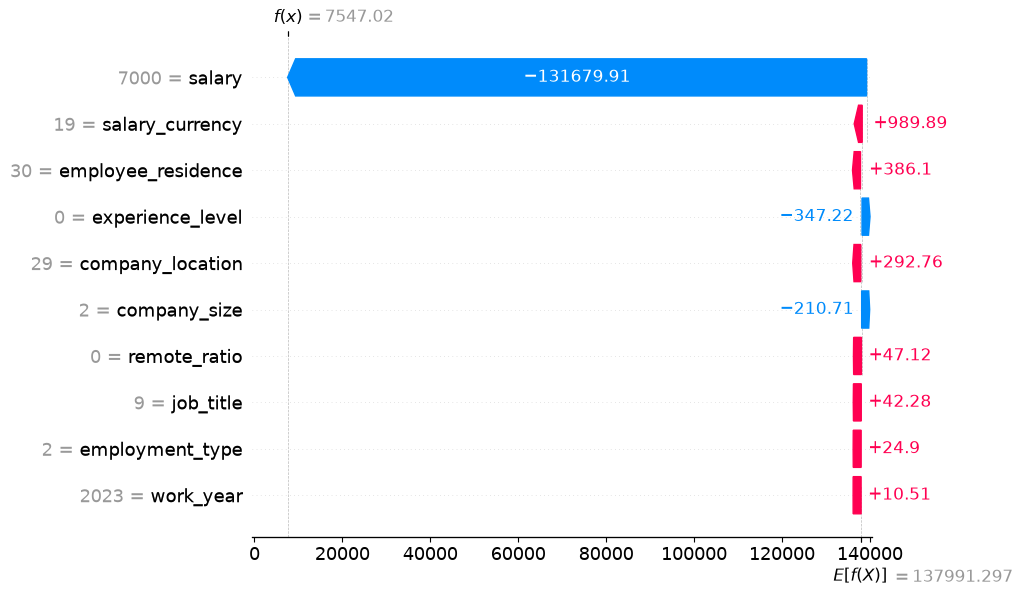

In [17]:
shap.plots.waterfall(shap_values[idx_low], max_display=12)

Nuevamente, `salary` es la variable que más contribuye, pero esta vez en dirección negativa (empujando la predicción por debajo del valor base). El patrón es espejo respecto a la observación A: salary alto → predicción alta, salary bajo → predicción baja.

En ambos casos, la explicación local es completamente coherente con el diagnóstico global (PFI): el modelo depende casi exclusivamente de `salary` para predecir.

### SHAP Beeswarm (visión global desde SHAP)

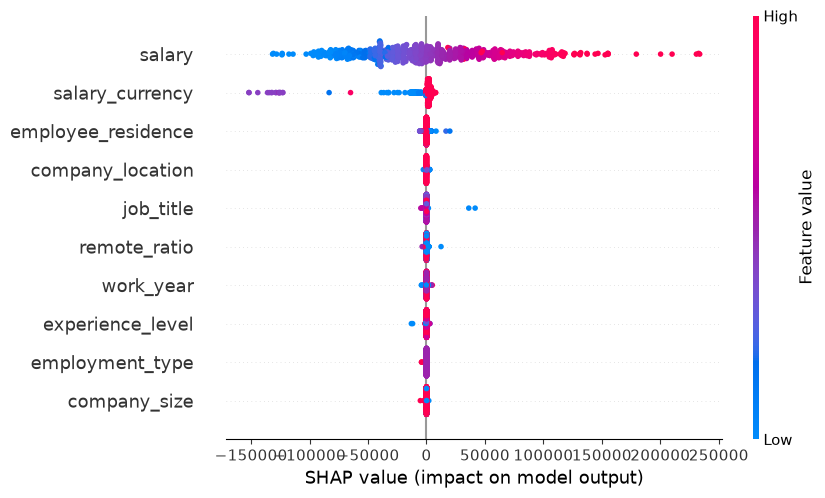

In [18]:
shap.plots.beeswarm(shap_values, max_display=12)

El beeswarm confirma que `salary` tiene un rango de impacto enormemente mayor que cualquier otra variable. Los valores altos de salary (puntos rojos) empujan fuertemente la predicción hacia arriba, y los bajos (azules) hacia abajo. El resto de las variables tienen un impacto mínimo en comparación.

## 5. Auditoría del modelo

### Hallazgo 1: Data leakage a través de `salary`

**Evidencia:**
- PFI muestra que `salary` concentra la mayor parte de la importancia del modelo.
- SHAP confirma que, tanto en predicciones altas como bajas, `salary` es prácticamente la única variable que determina el resultado.
- El beeswarm muestra una relación lineal casi perfecta entre el valor de `salary` y su impacto en la predicción.

**¿Es razonable?** No. La variable `salary` es el salario en moneda local, y el target `salary_in_usd` es su equivalente en dólares. Son esencialmente la misma información, transformada por un tipo de cambio. Esto constituye un caso clásico de **data leakage**: el modelo no está aprendiendo qué factores determinan un salario alto, sino simplemente convirtiendo monedas.

**Causa:** El dataset incluye tanto el salario original como su conversión a USD. En un escenario real de predicción, no dispondríamos de `salary` si queremos predecir `salary_in_usd`.

**Acción:** Eliminar `salary` y `salary_currency` del modelo y reentrenar.

### Hallazgo 2: `salary_currency` como información redundante

**Evidencia:** `salary_currency` aparece con importancia relevante en el PFI y en SHAP. Esto se debe a que actúa como factor de conversión implícito entre `salary` y `salary_in_usd`.

**Causa:** Es información derivada del mismo proceso que genera el leakage.

**Acción:** Eliminarla junto con `salary`.

### Hallazgo 3: Variables legítimas con importancia marginal

**Evidencia:** Variables como `experience_level`, `job_title` y `company_size` tienen importancia cercana a cero en presencia de `salary`.

**¿Es razonable?** Sí, bajo el contexto de leakage. El modelo no necesita estas variables porque `salary` ya contiene toda la información necesaria. Una vez eliminado el leakage, esperamos que estas variables recuperen su importancia natural.

## 6. Reentrenamiento sin leakage

In [19]:
leak_cols = ['salary', 'salary_currency']
X_clean = X_encoded.drop(columns=leak_cols)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y, test_size=0.2, random_state=42
)

model_clean = RandomForestRegressor(random_state=42)
model_clean.fit(X_train_c, y_train_c)

y_pred_c = model_clean.predict(X_test_c)

print('Comparación de métricas:')
print(f'{"Métrica":<10} {"Con leakage":>15} {"Sin leakage":>15}')
print(f'{"R²":<10} {r2_score(y_test, y_pred):>15.4f} {r2_score(y_test_c, y_pred_c):>15.4f}')
print(f'{"MAE":<10} {mean_absolute_error(y_test, y_pred):>15,.0f} {mean_absolute_error(y_test_c, y_pred_c):>15,.0f}')
print(f'{"RMSE":<10} {np.sqrt(mean_squared_error(y_test, y_pred)):>15,.0f} {np.sqrt(mean_squared_error(y_test_c, y_pred_c)):>15,.0f}')

Comparación de métricas:
Métrica        Con leakage     Sin leakage
R²                  0.9761          0.3883
MAE                  1,524          37,178
RMSE                 9,717          49,141


Como era de esperarse, la performance cae significativamente al eliminar el leakage. El R² alto del modelo original era artificial: el modelo estaba "haciendo trampa" al usar una variable que es esencialmente el target.

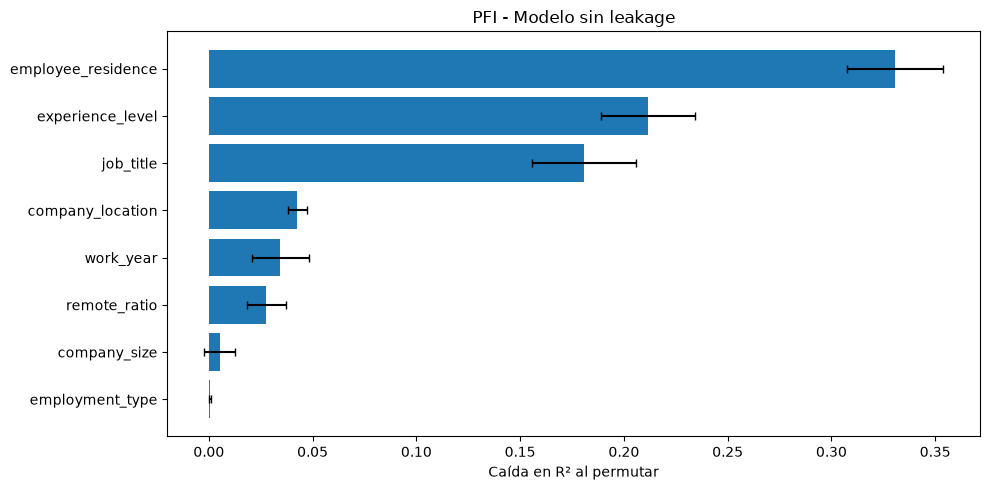

,feature,importance_mean,importance_std
4,employee_residence,0.330726,0.023066
1,experience_level,0.211684,0.022706
3,job_title,0.180687,0.025196
6,company_location,0.042659,0.004718
0,work_year,0.034498,0.013625
5,remote_ratio,0.027747,0.009374
7,company_size,0.005209,0.007379
2,employment_type,0.000712,0.000545


In [20]:
pfi_clean = permutation_importance(
    model_clean, X_test_c, y_test_c,
    n_repeats=30,
    random_state=42,
    scoring='r2'
)

pfi_clean_df = pd.DataFrame({
    'feature': X_test_c.columns,
    'importance_mean': pfi_clean.importances_mean,
    'importance_std': pfi_clean.importances_std
}).sort_values('importance_mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
pfi_sorted_c = pfi_clean_df.sort_values('importance_mean', ascending=True)
ax.barh(pfi_sorted_c['feature'], pfi_sorted_c['importance_mean'],
        xerr=pfi_sorted_c['importance_std'], capsize=3)
ax.set_xlabel('Caída en R² al permutar')
ax.set_title('PFI - Modelo sin leakage')
plt.tight_layout()
plt.show()

pfi_clean_df

### Comparación de importancia de variables

Sin el leakage, las variables relevantes para el problema emergen con importancia razonable:
- **experience_level:** el nivel de experiencia es uno de los factores más determinantes del salario, lo cual tiene sentido desde el dominio.
- **job_title:** el puesto de trabajo también influye, como es esperable.
- **employee_residence / company_location:** la ubicación geográfica afecta los salarios (diferencias entre países).

Este ranking de importancia es mucho más razonable y coherente con el conocimiento del dominio que el modelo original, donde `salary` opacaba todo.

## 7. Conclusiones

1. El modelo original presentaba un caso claro de **data leakage**: la variable `salary` es una transformación directa del target (`salary_in_usd`), inflando artificialmente la performance.

2. Las técnicas de interpretabilidad (PFI y SHAP) fueron efectivas para detectar este problema:
   - PFI reveló la importancia desproporcionada de `salary`.
   - SHAP confirmó que cada predicción individual dependía casi exclusivamente de esta variable.

3. Al eliminar las variables con leakage, la performance cae pero el modelo se vuelve más razonable: las variables con mayor importancia son las que un experto del dominio esperaría (experiencia, puesto, ubicación).

4. El modelo limpio tiene menor capacidad predictiva, lo cual es esperable: predecir salarios es un problema intrínsecamente difícil con alta variabilidad.